In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Re-run the Feature Engineering from Phase 4 ---
# (This ensures our notebook is self-contained)
processed_data_path = '../data/processed/measles_cases_processed_timeseries.csv'
df_cases = pd.read_csv(processed_data_path, index_col='Year', parse_dates=True)

df_long = df_cases.melt(ignore_index=False, var_name='CountryCode', value_name='Cases').reset_index()
df_long.sort_values(by=['CountryCode', 'Year'], inplace=True)
df_long['Cases_Next_Year'] = df_long.groupby('CountryCode')['Cases'].shift(-1)
df_long['Cases_Lag_1'] = df_long.groupby('CountryCode')['Cases'].shift(1)
df_long['Year_Num'] = df_long['Year'].dt.year
df_final = df_long.dropna(subset=['Cases_Next_Year', 'Cases_Lag_1'])

# --- 2. Train the Model on ALL Available Data ---
features = ['Cases', 'Cases_Lag_1', 'Year_Num']
target = 'Cases_Next_Year'
X_full = df_final[features]
y_full = df_final[target]

model_full = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05)
print("--- Training model on all available data... ---")
model_full.fit(X_full, y_full, verbose=False)
print("--- Model training complete. ---")


# --- 3. Prepare the data to forecast the next year ---
# We take the most recent year's data from our original long-form df
most_recent_year_data = df_long[df_long['Year'] == df_long['Year'].max()].copy()

# *** FIX IS HERE ***
# We drop the old 'Cases_Lag_1' column which is full of NaNs for this slice of data.
if 'Cases_Lag_1' in most_recent_year_data.columns:
    most_recent_year_data.drop(columns=['Cases_Lag_1'], inplace=True)

# We get the case data from the previous year to serve as our new lag feature
prev_year = df_long['Year'].max() - pd.DateOffset(years=1)
prev_year_cases = df_long[df_long['Year'] == prev_year][['CountryCode', 'Cases']]

# Merge to get the lag value correctly. Now it will create the 'Cases_Lag_1' column cleanly.
most_recent_year_data = pd.merge(most_recent_year_data, prev_year_cases.rename(columns={'Cases': 'Cases_Lag_1'}), on='CountryCode', how='left')

# The rest of the code remains the same
X_predict = most_recent_year_data[features].dropna()

# --- 4. Generate the Forecast ---
future_forecasts = model_full.predict(X_predict)
forecast_df = X_predict.copy()
forecast_df['Forecasted_Cases'] = np.maximum(0, future_forecasts) # Ensure predictions are not negative

# We need to re-add the CountryCode for later merging
forecast_df = pd.merge(forecast_df, most_recent_year_data[['CountryCode']], left_index=True, right_index=True, how='left')

print("\n--- Sample of Future Forecasts ---")
print(forecast_df.head())

--- Training model on all available data... ---
--- Model training complete. ---

--- Sample of Future Forecasts ---
     Cases  Cases_Lag_1  Year_Num  Forecasted_Cases CountryCode
0      0.0          0.0      2024          9.015202         ABW
1    207.0         61.0      2024        313.214844         AFG
2  15605.0      18684.0      2024      11331.531250         AFR
3      0.0          0.0      2024          9.015202         AGO
4      0.0          0.0      2024          9.015202         AIA


In [4]:
# --- Calculate historical stats for risk scoring ---
# We'll use the last 10 years of data for a rolling average and standard deviation
end_year = df_cases.index.max().year
start_year = end_year - 10

historical_stats = df_cases.loc[str(start_year):str(end_year)].agg(['mean', 'std']).transpose()
historical_stats.rename(columns={'mean': 'Mean_Cases_10Y', 'std': 'Std_Cases_10Y'}, inplace=True)
historical_stats.fillna(0, inplace=True) # Fill std for countries with constant cases

# --- Merge forecasts with historical stats ---
results_df = pd.merge(forecast_df, historical_stats, left_on='CountryCode', right_index=True)

# --- Define the risk scoring function ---
def assign_risk_level(row):
    mean = row['Mean_Cases_10Y']
    std = row['Std_Cases_10Y']
    forecast = row['Forecasted_Cases']
    
    # Handle cases with zero standard deviation (flat history)
    if std == 0:
        if forecast > mean:
            return 'High'
        else:
            return 'Low'

    if forecast > mean + (2 * std):
        return 'High'
    elif forecast > mean + std:
        return 'Medium'
    else:
        return 'Low'

# --- Apply the function to create the 'Risk_Level' column ---
results_df['Risk_Level'] = results_df.apply(assign_risk_level, axis=1)

print("\n--- Results with Risk Levels ---")
print(results_df[['CountryCode', 'Forecasted_Cases', 'Mean_Cases_10Y', 'Risk_Level']].head())


--- Results with Risk Levels ---
  CountryCode  Forecasted_Cases  Mean_Cases_10Y Risk_Level
0         ABW          9.015202        0.000000       High
1         AFG        313.214844       34.818182       High
2         AFR      11331.531250     6115.454545        Low
3         AGO          9.015202        0.000000       High
4         AIA          9.015202        0.000000       High


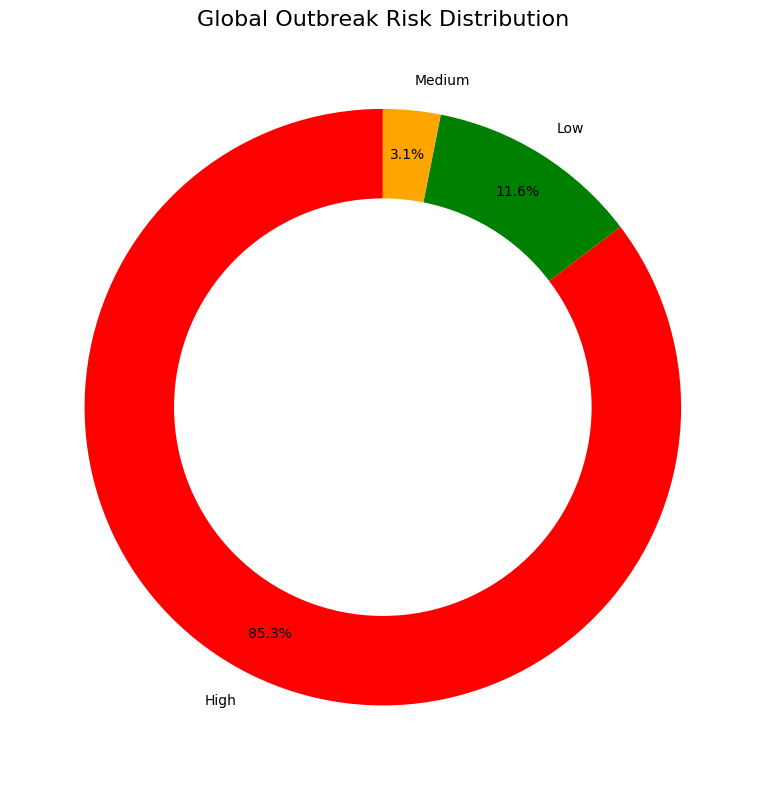

In [5]:
# --- Outbreak Radar (Donut Chart) ---
risk_counts = results_df['Risk_Level'].value_counts()
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
labels = risk_counts.index

plt.figure(figsize=(8, 8))
plt.pie(risk_counts, labels=labels, autopct='%1.1f%%', startangle=90,
        pctdistance=0.85, colors=[colors[key] for key in labels])

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Global Outbreak Risk Distribution', fontsize=16)
plt.tight_layout()
plt.show()

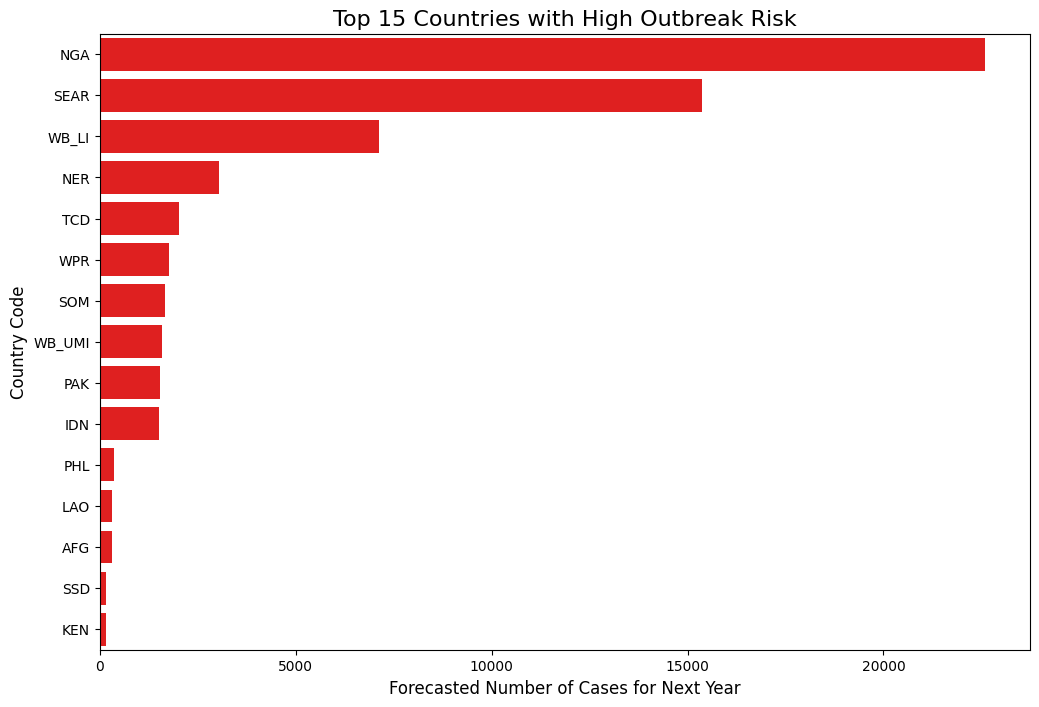

In [6]:
# --- Top 10 High-Risk Countries by Forecasted Cases ---
high_risk_df = results_df[results_df['Risk_Level'] == 'High'].sort_values(by='Forecasted_Cases', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Forecasted_Cases', y='CountryCode', data=high_risk_df.head(15), color='red')
plt.title('Top 15 Countries with High Outbreak Risk', fontsize=16)
plt.xlabel('Forecasted Number of Cases for Next Year', fontsize=12)
plt.ylabel('Country Code', fontsize=12)
plt.show()